<a href="https://colab.research.google.com/github/LuizLott/OTCprojectUniversity/blob/main/testeTrabalhoOTC0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Preço médio histórico: R$ 1227.68/saca
 Preço máximo: R$ 2446.64 | Mínimo: R$ 556.99
                            OLS Regression Results                            
Dep. Variable:             preco_saca   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     61.26
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           1.20e-10
Time:                        02:36:51   Log-Likelihood:                -438.41
No. Observations:                  60   AIC:                             880.8
Df Residuals:                      58   BIC:                             885.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

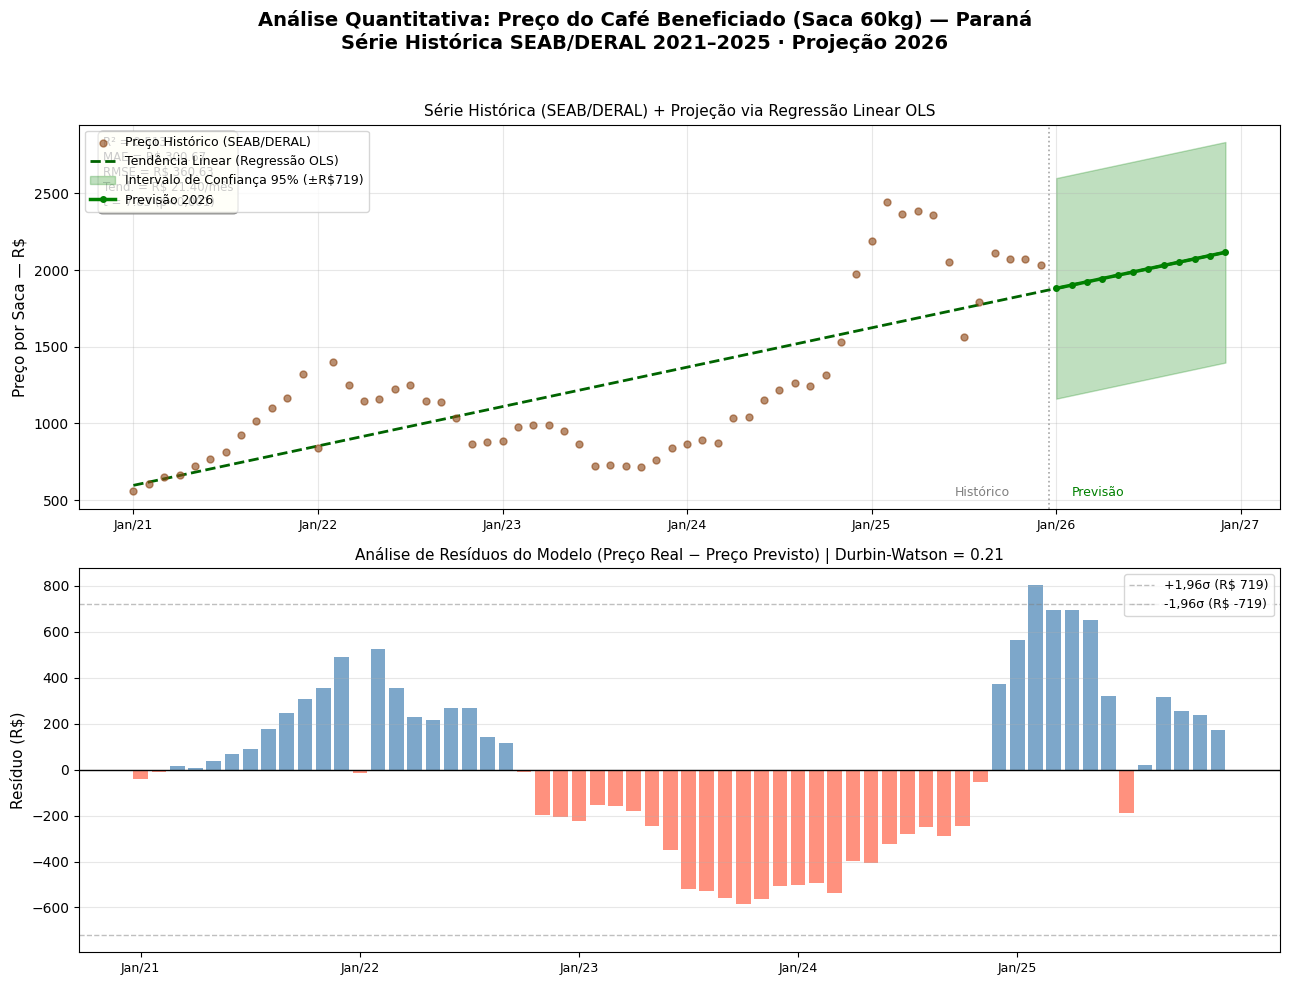

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# 2. DADOS(SEAB/DERAL)
# Preço recebido pelo produtor, café cru, R$/saca 60kg
dados = {
    2021: [556.99, 606.40, 653.62, 666.43, 719.61, 771.31, 816.28, 924.44, 1014.89, 1098.42, 1166.18, 1320.51],
    2022: [839.63, 1397.36, 1251.61, 1146.90, 1156.78, 1227.67, 1250.03, 1145.80, 1140.86, 1033.83, 869.29, 880.61],
    2023: [888.14, 978.06, 993.10, 992.14, 948.33, 866.77, 720.90, 729.77, 720.57, 718.36, 761.66, 839.63],
    2024: [866.51, 895.34, 871.58, 1033.73, 1045.23, 1151.55, 1216.21, 1265.98, 1247.17, 1313.44, 1529.04, 1975.26],
    2025: [2186.91, 2446.64, 2362.81, 2384.51, 2361.33, 2050.43, 1564.61, 1793.12, 2109.09, 2070.56, 2075.10, 2031.99],
}

precos, datas = [], []
for ano in sorted(dados.keys()):
    for i, v in enumerate(dados[ano]):
        precos.append(v)
        datas.append(pd.Timestamp(year=ano, month=i + 1, day=1))

df_historico = pd.DataFrame({'data': datas, 'preco_saca': precos})
df_historico['mes_idx'] = np.arange(1, len(df_historico) + 1)

print(f' Preço médio histórico: R$ {df_historico["preco_saca"].mean():.2f}/saca')
print(f' Preço máximo: R$ {df_historico["preco_saca"].max():.2f} | Mínimo: R$ {df_historico["preco_saca"].min():.2f}')
df_historico.head(6)

# --- 3. REGRESSÃO LINEAR (OLS) COM STATSMODELS ---
X = sm.add_constant(df_historico['mes_idx'])
y = df_historico['preco_saca']
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

y_pred = modelo.predict(X)
residuos = (y - y_pred).values

beta0 = modelo.params['const']
beta1 = modelo.params['mes_idx']

# --- 4. MÉTRICAS DE AJUSTE ---
r2 = modelo.rsquared
mae = np.mean(np.abs(residuos))
rmse = np.sqrt(np.mean(residuos ** 2))

print('\n Métricas de Avaliação do Modelo:')
print(f'   R²   = {r2:.4f}  → {r2*100:.1f}% da variância explicada pela tendência linear')
print(f'   MAE  = R$ {mae:.2f}  → erro médio absoluto por saca')
print(f'   RMSE = R$ {rmse:.2f}  → penaliza erros grandes (sempre RMSE ≥ MAE)')
print(f'   Coeficiente angular (β₁): R$ {beta1:.2f}/mês')
print(f'   Intercepto (β₀): R$ {beta0:.2f}')

# --- 5. TESTES ESTATÍSTICOS ---
t_beta1 = modelo.tvalues['mes_idx']
p_beta1 = modelo.pvalues['mes_idx']
f_stat = modelo.fvalue
f_pvalue = modelo.f_pvalue
sw_stat, sw_pvalue = stats.shapiro(residuos)
dw_stat = sm.stats.stattools.durbin_watson(residuos)

print('\n Testes Estatísticos:')
print(f'   Teste t (H0: β1=0):        t = {t_beta1:.2f}   p-valor = {p_beta1:.2e}')
print(f'   Teste F (significância global): F = {f_stat:.2f}   p-valor = {f_pvalue:.2e}')
print(f'   Shapiro-Wilk (normalidade dos resíduos): W = {sw_stat:.4f}   p-valor = {sw_pvalue:.4f}')
print(f'   Durbin-Watson (autocorrelação dos resíduos): DW = {dw_stat:.3f}')
print('   (DW próximo de 2 = sem autocorrelação; DW baixo = autocorrelação positiva)')

# --- 6. PROJEÇÃO 2026 COM INTERVALO DE CONFIANÇA 95% ---
meses_futuros = np.arange(61, 73)
datas_futuras = pd.date_range(start='2026-01-01', periods=12, freq='MS')
X_futuro = sm.add_constant(meses_futuros, has_constant='add')
previsao = modelo.predict(X_futuro)

std_residuos = residuos.std(ddof=2)
margem_ic95 = 1.96 * std_residuos

df_previsao = pd.DataFrame({
    'data': datas_futuras,
    'previsao': previsao,
    'limite_inferior': previsao - margem_ic95,
    'limite_superior': previsao + margem_ic95
})

print('\n Projeção de Preços — Jan a Dez/2026:')
print(df_previsao.to_string(index=False, float_format='R$ {:,.2f}'.format))

# --- 7. GRÁFICOS ---
fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle('Análise Quantitativa: Preço do Café Beneficiado (Saca 60kg) — Paraná\n'
             'Série Histórica SEAB/DERAL 2021–2025 · Projeção 2026',
             fontsize=14, fontweight='bold', y=0.98)

# --- Gráfico 1: Série histórica + tendência + previsão + IC ---
ax1 = axes[0]

todos_meses = np.concatenate([df_historico['mes_idx'].values, meses_futuros])
X_completo = sm.add_constant(todos_meses, has_constant='add')
tendencia_completa = modelo.predict(X_completo)

ax1.scatter(df_historico['mes_idx'], df_historico['preco_saca'],
            color='saddlebrown', alpha=0.6, s=25, zorder=3, label='Preço Histórico (SEAB/DERAL)')

ax1.plot(todos_meses, tendencia_completa,
         color='darkgreen', linestyle='--', linewidth=2, label='Tendência Linear (Regressão OLS)')

ax1.fill_between(meses_futuros, previsao - margem_ic95, previsao + margem_ic95,
                  alpha=0.25, color='green', label=f'Intervalo de Confiança 95% (±R${margem_ic95:.0f})')

ax1.plot(meses_futuros, previsao,
         color='green', linewidth=2.5, marker='o', markersize=4, label='Previsão 2026')

ax1.axvline(x=60.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
ax1.text(58, df_historico['preco_saca'].min() * 0.95, 'Histórico', ha='right', color='gray', fontsize=9)
ax1.text(62, df_historico['preco_saca'].min() * 0.95, 'Previsão', ha='left', color='green', fontsize=9)

ticks_pos = [1, 13, 25, 37, 49, 61, 73]
ticks_lbl = ['Jan/21', 'Jan/22', 'Jan/23', 'Jan/24', 'Jan/25', 'Jan/26', 'Jan/27']
ax1.set_xticks(ticks_pos)
ax1.set_xticklabels(ticks_lbl, fontsize=9)

ax1.set_ylabel('Preço por Saca — R$', fontsize=11)
ax1.set_title('Série Histórica (SEAB/DERAL) + Projeção via Regressão Linear OLS', fontsize=11)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

txt_metricas = (f"R² = {r2:.4f}\n"
                f"MAE = R$ {mae:.2f}\n"
                f"RMSE = R$ {rmse:.2f}\n"
                f"Tend. = R$ {beta1:.2f}/mês\n"
                f"t = {t_beta1:.2f} (p<0,001)")
ax1.text(0.02, 0.97, txt_metricas, transform=ax1.transAxes,
          fontsize=8.5, va='top', ha='left',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

# --- Gráfico 2: Análise de Resíduos ---
ax2 = axes[1]
cores = np.where(residuos >= 0, 'steelblue', 'tomato')
ax2.bar(df_historico['mes_idx'], residuos, color=cores, alpha=0.7, width=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.axhline(margem_ic95, color='gray', linewidth=1, linestyle='--', alpha=0.5,
            label=f'+1,96σ (R$ {margem_ic95:.0f})')
ax2.axhline(-margem_ic95, color='gray', linewidth=1, linestyle='--', alpha=0.5,
            label=f'-1,96σ (R$ {-margem_ic95:.0f})')

ax2.set_xticks([1, 13, 25, 37, 49])
ax2.set_xticklabels(['Jan/21', 'Jan/22', 'Jan/23', 'Jan/24', 'Jan/25'], fontsize=9)
ax2.set_ylabel('Resíduo (R$)', fontsize=11)
ax2.set_title(f'Análise de Resíduos do Modelo (Preço Real − Preço Previsto) | Durbin-Watson = {dw_stat:.2f}',
              fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('serie_preditiva_cafe_real.png', dpi=150, bbox_inches='tight')
plt.show()
